**Problem Statement**

The objective of this project is to predict the type of drug a patient should be prescribed based on medical attributes such as age, sex, blood pressure, cholesterol level, and sodium-to-potassium ratio.

This is a multi-class classification problem.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from scipy.stats import chi2_contingency

In [3]:
data=pd.read_csv('/kaggle/input/datasets/prathamtripathi/drug-classification/drug200.csv')
print(data)

     Age Sex      BP Cholesterol  Na_to_K   Drug
0     23   F    HIGH        HIGH   25.355  DrugY
1     47   M     LOW        HIGH   13.093  drugC
2     47   M     LOW        HIGH   10.114  drugC
3     28   F  NORMAL        HIGH    7.798  drugX
4     61   F     LOW        HIGH   18.043  DrugY
..   ...  ..     ...         ...      ...    ...
195   56   F     LOW        HIGH   11.567  drugC
196   16   M     LOW        HIGH   12.006  drugC
197   52   M  NORMAL        HIGH    9.894  drugX
198   23   M  NORMAL      NORMAL   14.020  drugX
199   40   F     LOW      NORMAL   11.349  drugX

[200 rows x 6 columns]


**Dataset Overview**

Total Records: 200
**Features:**

1. Age (Numerical)
2. Sex (Categorical)
3. BP (Categorical)
4. Cholesterol (Categorical)
5. Na_to_K (Numerical)

**Target:**
Drug (Categorical)

In [4]:
# Basic data check
data.head()
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

count    200.000000
mean      44.315000
std       16.544315
min       15.000000
25%       31.000000
50%       45.000000
75%       58.000000
max       74.000000
Name: Age, dtype: float64

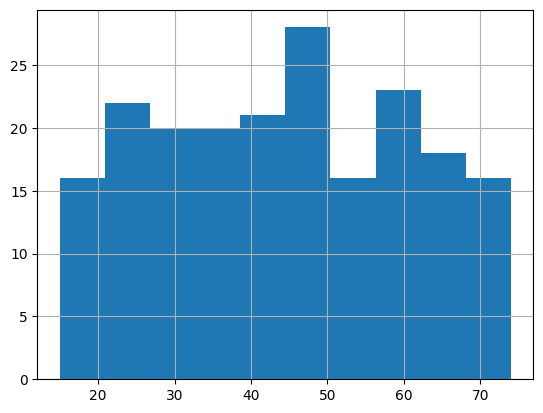

In [5]:
data['Age'].hist()
data['Age'].describe()

**Exploratory Data Analysis**

a. Univariate Analysis

1. Age and Na_to_K distributions were analyzed using histograms

2. Categorical features like BP, Cholesterol, and Drug were analyzed using count plots

3. Drug classes were found to be reasonably balanced


b. Bivariate Analysis

1.Na_to_K showed strong separation across drug categories

2.BP and Cholesterol showed clear influence on drug selection

3.Sex showed minimal variation across drug types

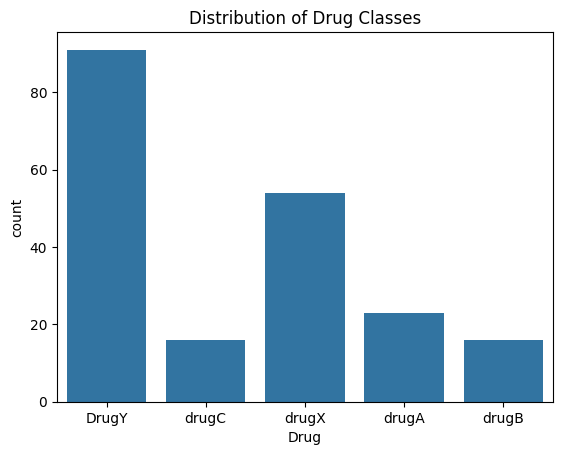

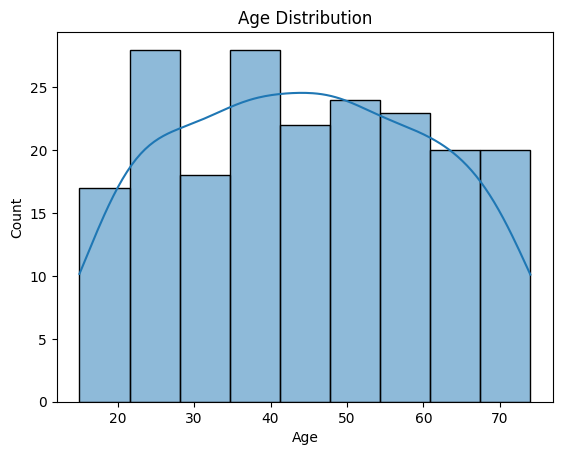

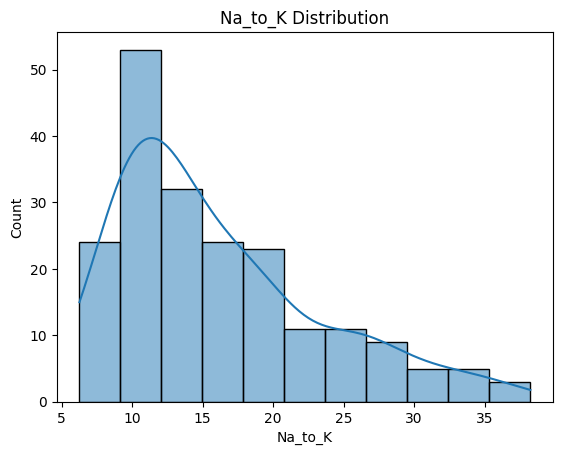

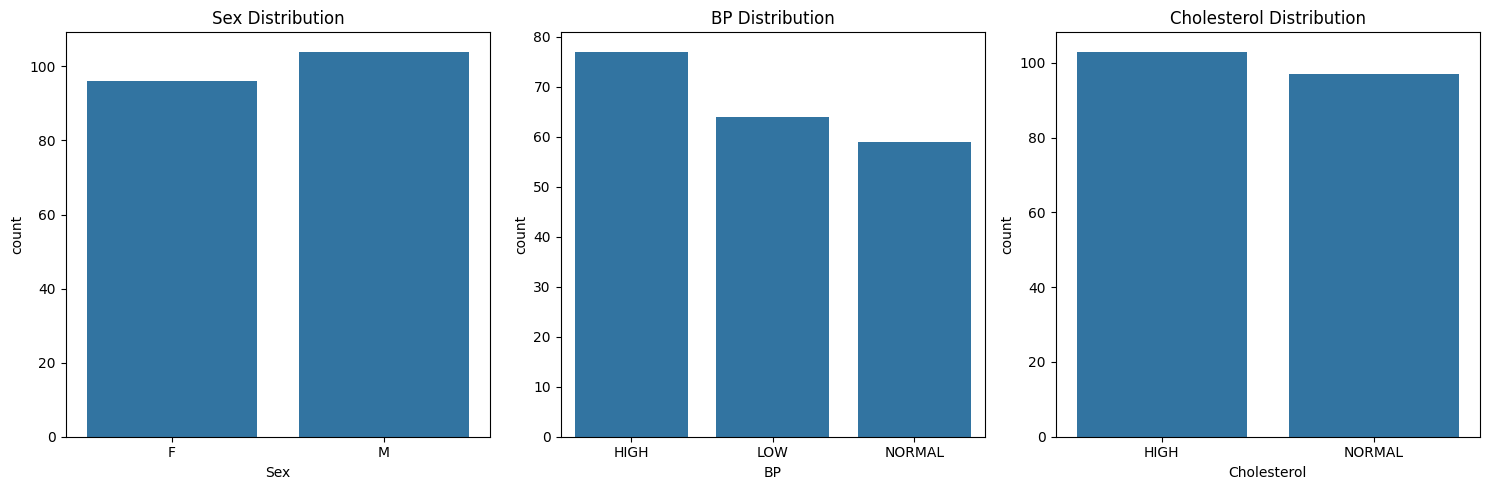

In [6]:
#UNIVARIATE ANALYSIS
#1.Target Variable (Drug)
sns.countplot(x='Drug', data=data)
plt.title("Distribution of Drug Classes")
plt.show()

#2 Age Distribution
sns.histplot(data['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

#3 Na_to_K Distribution (VERY IMPORTANT ⭐)
sns.histplot(data['Na_to_K'], kde=True)
plt.title("Na_to_K Distribution")
plt.show()

#4 Categorical Variables
fig, ax = plt.subplots(1, 3, figsize=(15,5))

sns.countplot(x='Sex', data=data, ax=ax[0])
ax[0].set_title("Sex Distribution")

sns.countplot(x='BP', data=data, ax=ax[1])
ax[1].set_title("BP Distribution")

sns.countplot(x='Cholesterol', data=data, ax=ax[2])
ax[2].set_title("Cholesterol Distribution")

plt.tight_layout()
plt.show()

**Univariate Analysis Findings:**

1. Na_to_K is highly skewed and important
2. BP has multiple levels and strong variation
3. Drug classes are fairly balanced


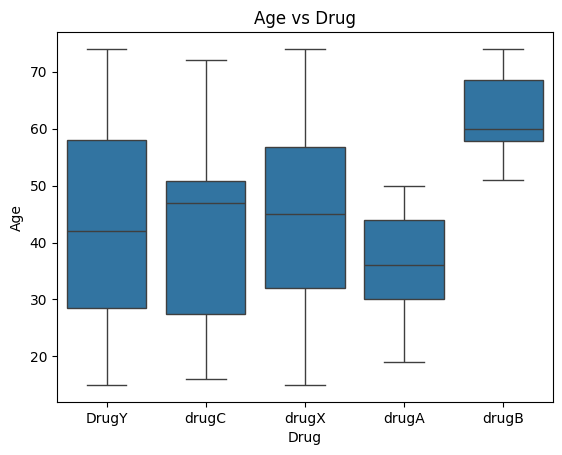

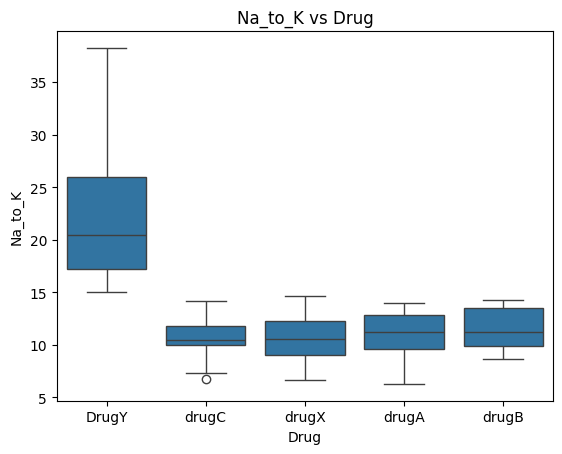

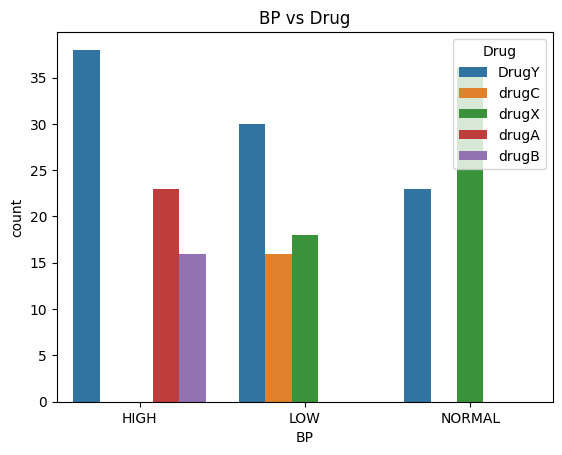

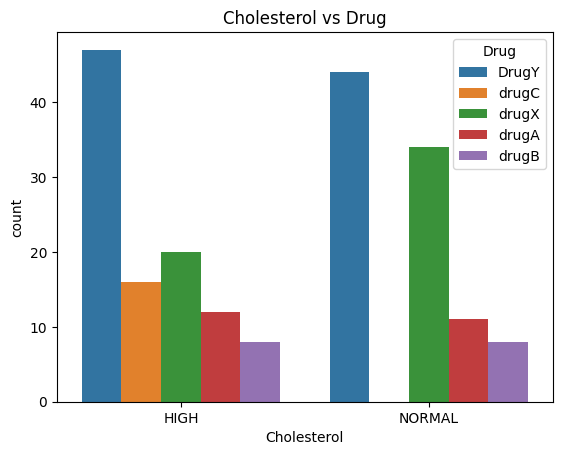

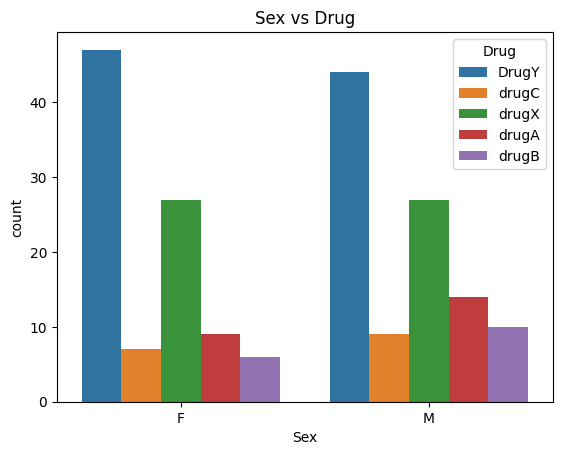

In [7]:
#2. BIVARIATE ANALYSIS
## Goal: Relationship between features and target (Drug)

#1 Age vs Drug
sns.boxplot(x='Drug', y='Age', data=data)
plt.title("Age vs Drug")
plt.show()

#2 Na_to_K vs Drug (MOST IMPORTANT)
sns.boxplot(x='Drug', y='Na_to_K', data=data)
plt.title("Na_to_K vs Drug")
plt.show()

#3 BP vs Drug
sns.countplot(x='BP', hue='Drug', data=data)
plt.title("BP vs Drug")
plt.show()

#4 Cholesterol vs Drug
sns.countplot(x='Cholesterol', hue='Drug', data=data)
plt.title("Cholesterol vs Drug")
plt.show()

#5 Sex vs Drug
sns.countplot(x='Sex', hue='Drug', data=data)
plt.title("Sex vs Drug")
plt.show()

**Bivariate Analysis Findings:**

1. Na_to_K strongly separates drug types
2. BP and Cholesterol significantly influence drug choice
3. Age has mild impact
4. Sex has minimal impact


**CHI-SQUARE TEST**

Verify the relationship between categorical features and target.

In [8]:
categorical_cols = ['Sex', 'BP', 'Cholesterol']

for col in categorical_cols:
    print(f"\n{col} vs Drug")

    cont_table = pd.crosstab(data[col], data['Drug'])
    chi2, p, dof, expected = chi2_contingency(cont_table)

    print("P-value:", p)

    if p < 0.05:
        print(" Significant relationship with Drug")
    else:
        print(" No significant relationship")


Sex vs Drug
P-value: 0.7138369773987128
 No significant relationship

BP vs Drug
P-value: 5.0417334144665895e-27
 Significant relationship with Drug

Cholesterol vs Drug
P-value: 0.0005962588389856497
 Significant relationship with Drug


**CHI-SQUARE TEST Analysis**

1. BP has strongest relationship with Drug.
2. Cholesterol also influences Drug selection.
3. Sex does not significantly affect Drug prediction.


**Feature Engineering**

1. Converted categorical variables into numerical format using Label Encoding.
2. Removed less important features based on statistical testing.
3. Applied scaling for SVM model to improve performance.


In [9]:
le = LabelEncoder()

data['Sex'] = le.fit_transform(data['Sex'])
data['BP'] = le.fit_transform(data['BP'])
data['Cholesterol'] = le.fit_transform(data['Cholesterol'])
data['Drug'] = le.fit_transform(data['Drug'])
print("Encoding completed successfully ")
print(data.head())

Encoding completed successfully 
   Age  Sex  BP  Cholesterol  Na_to_K  Drug
0   23    0   0            0   25.355     0
1   47    1   1            0   13.093     3
2   47    1   1            0   10.114     3
3   28    0   2            0    7.798     4
4   61    0   1            0   18.043     0


In [10]:
#Features & Target
X = data.drop('Drug', axis=1)
y = data['Drug']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (200, 5)
Target shape: (200,)


**Train Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (160, 5)
Test shape: (40, 5)


**Model Building**

The following models were trained and evaluated:
1. Decision Tree
2. Random Forest
3. Support Vector Machine (SVM)


In [12]:
#MODEL 1 — Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("\nDecision Tree Model Trained ")
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Model Trained 
Decision Tree Accuracy: 0.975


In [13]:
#MODEL 2 — Random Forest 
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\nRandom Forest Model Trained ")
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Model Trained 
Random Forest Accuracy: 0.975


In [14]:
#MODEL 3 — SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("\nSVM Model Trained ")
print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))


SVM Model Trained 
SVM Test Accuracy: 0.975


**Train vs Test Accuracy Prediction**

In [15]:
#1. Define Decision Tree accuracies
dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_test_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Train Accuracy:", dt_train_acc)
print("Decision Tree Test Accuracy:", dt_test_acc)

Decision Tree Train Accuracy: 1.0
Decision Tree Test Accuracy: 0.975


In [16]:
#2. Define Random Forest accuracies
rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_test_acc = accuracy_score(y_test, y_pred_rf)

print("Random Forest Train Accuracy:", rf_train_acc)
print("Random Forest Test Accuracy:", rf_test_acc)

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.975


In [17]:
#3. Define SVM accuracies
svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train))
svm_test_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Train Accuracy:", svm_train_acc)
print("SVM Test Accuracy:", svm_test_acc)

SVM Train Accuracy: 1.0
SVM Test Accuracy: 0.975


**MODEL COMPARISON**

In [18]:
print("\n===== MODEL COMPARISON =====")

print("\nDecision Tree:")
print("Train:", dt_train_acc)
print("Test:", dt_test_acc)

print("\nRandom Forest:")
print("Train:", rf_train_acc)
print("Test:", rf_test_acc)

print("\nSVM:")
print("Train:", svm_train_acc)
print("Test:", svm_test_acc)


===== MODEL COMPARISON =====

Decision Tree:
Train: 1.0
Test: 0.975

Random Forest:
Train: 1.0
Test: 0.975

SVM:
Train: 1.0
Test: 0.975


In [19]:
#Cross Validation (SVM)
from sklearn.model_selection import cross_val_score

svm_cv_scores = cross_val_score(svm_model, X, y, cv=5)

print("\n===== SVM CROSS VALIDATION =====")
print("CV Scores:", svm_cv_scores)
print("Mean CV Score:", svm_cv_scores.mean())


===== SVM CROSS VALIDATION =====
CV Scores: [1.   1.   1.   0.95 1.  ]
Mean CV Score: 0.99


In [21]:
#FINAL MODEL SELECTION
models = {
    "Decision Tree": dt_test_acc,
    "Random Forest": rf_test_acc,
    "SVM": svm_test_acc
}

best_model = max(models, key=models.get)

print("\n===== BEST MODEL =====")
print("Best Model:", best_model)
print("Best Accuracy:", models[best_model])


===== BEST MODEL =====
Best Model: Decision Tree
Best Accuracy: 0.975
